In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Churn_Modelling.csv")

#### Problem Statement

In [3]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
## missing values check
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
# Converison of categorical data
Geography = pd.get_dummies(data.Geography,drop_first = True)

In [6]:
Geography

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,True,False


In [7]:
Gender=pd.get_dummies(data.Gender,drop_first=True)

In [8]:
Gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [9]:
data=pd.concat([data,Geography,Gender],axis=1)

In [10]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [11]:
data.drop(['Geography','Gender'],axis=1,inplace=True)

In [12]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [13]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Germany', 'Spain', 'Male'],
      dtype='object')

In [14]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [15]:
## Creating independent and dependent variable.
X= data.loc [:,['CreditScore', 'Age', 'Tenure','Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary','Germany', 'Spain', 'Male']]
y = data.Exited

In [16]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [17]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [18]:
## Training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=20,test_size=0.2)

In [19]:
X_train.shape

(8000, 11)

In [20]:
X_test.shape

(2000, 11)

In [21]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
4661,780,43,0,0.00,1,0,1,15705.27,False,False,False
7168,507,33,7,0.00,2,1,1,85411.01,False,False,True
1031,631,22,3,0.00,2,0,0,30781.77,False,False,False
6746,640,39,3,0.00,1,1,1,105997.25,False,True,True
9228,699,39,2,109724.38,1,1,1,180022.39,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
3915,686,43,2,134896.03,1,1,1,97847.05,True,False,True
9620,561,37,4,101470.29,1,0,1,88838.14,False,True,True
7068,699,54,3,111009.32,1,1,1,155905.79,True,False,False
7391,430,31,5,0.00,1,1,0,95655.16,False,False,True


In [22]:
X_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
9957,633,25,1,0.00,1,1,0,100598.98,False,False,True
1687,850,37,4,137204.77,1,1,1,28865.59,False,True,True
2116,701,44,7,0.00,2,1,0,23425.78,False,False,True
231,610,40,0,0.00,2,1,0,62232.60,False,False,True
2780,778,40,8,104291.41,2,1,1,117507.11,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
7176,495,39,8,120252.02,2,1,1,10160.23,True,False,True
5050,703,32,1,125685.79,1,1,1,56246.72,False,False,True
7910,561,28,6,123692.00,1,1,1,70548.96,False,True,True
7023,524,29,9,144287.60,2,1,0,32063.30,True,False,True


In [23]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [24]:
X_train

array([[ 1.34111823,  0.38693948, -1.73661451, ..., -0.57965968,
        -0.58042949, -1.08948952],
       [-1.4670728 , -0.57127623,  0.69033796, ..., -0.57965968,
        -0.58042949,  0.91786105],
       [-0.19155746, -1.62531351, -0.69649202, ..., -0.57965968,
        -0.58042949, -1.08948952],
       ...,
       [ 0.5079187 ,  1.44097676, -0.69649202, ...,  1.72515018,
        -0.58042949, -1.08948952],
       [-2.25912668, -0.76291937, -0.00307703, ..., -0.57965968,
        -0.58042949,  0.91786105],
       [-0.78816947,  1.05769048, -1.73661451, ..., -0.57965968,
         1.72286214,  0.91786105]], shape=(8000, 11))

##### Import Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

##### Create the Random Forest model

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    criterion='gini',
    random_state=42
)

##### Train the model

In [27]:
rf_model.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Predict on test data

In [36]:
y_pred = rf_model.predict(X_test)

##### Accuracy

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8725


##### Confusion Matrix

In [38]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[1568   55]
 [ 200  177]]


##### Classification Report

In [39]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.92      1623
           1       0.76      0.47      0.58       377

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



##### Feature Importance

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
1               Age    0.243118
7   EstimatedSalary    0.144259
3           Balance    0.142813
0       CreditScore    0.140899
4     NumOfProducts    0.126946
2            Tenure    0.081374
6    IsActiveMember    0.042256
8           Germany    0.028038
5         HasCrCard    0.017966
10             Male    0.017770
9             Spain    0.014561


##### Visualize a feature importance

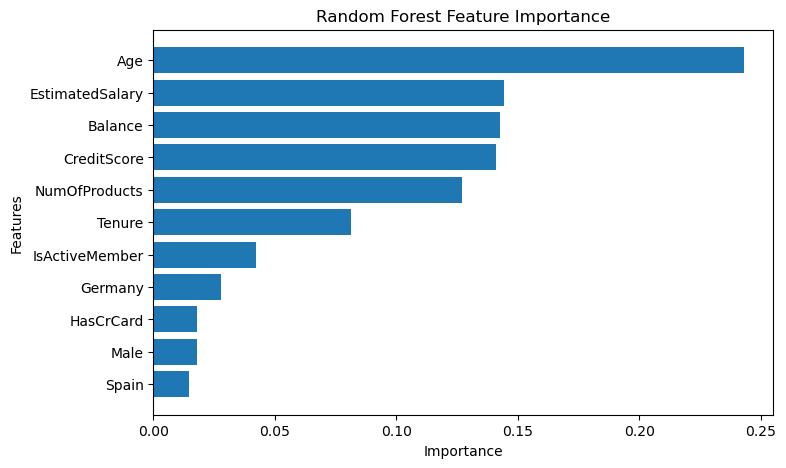

In [41]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

##### Save the Churn Model

In [34]:
import pickle

# Save Random Forest model
pickle.dump(rf_model, open("random_forest_churn_model.pkl", "wb"))

# Save Scaler
pickle.dump(sc, open("scaler.pkl", "wb"))

print("random_forest_churn_model.pkl and scaler.pkl saved successfully.")

random_forest_churn_model.pkl and scaler.pkl saved successfully.


Load the Model for Later Use

In [35]:
import pickle

rf_model = pickle.load(open("random_forest_churn_model.pkl", "rb"))
sc = pickle.load(open("scaler.pkl", "rb"))

# Predict for new data
prediction = rf_model.predict(X_test)